<a href="https://colab.research.google.com/github/beyza-ozdemir/simpsons-character-classification-cnn/blob/main/simpsons_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

characters = [
    "homer_simpson",
    "bart_simpson",
    "lisa_simpson",
    "marge_simpson",
    "maggie_simpson"
]

In [4]:
!unzip -q simpsons.zip -d simpsons_data

In [5]:
base_path = "simpsons_data/simpsons_dataset"

home_path = os.path.join(base_path, "homer_simpson")
images = os.listdir(home_path)

print("Homer resim sayısı:", len(images))
print("İlk 5 dosya:", images[:5])

Homer resim sayısı: 2246
İlk 5 dosya: ['pic_0996.jpg', 'pic_2189.jpg', 'pic_1055.jpg', 'pic_1810.jpg', 'pic_1336.jpg']


In [7]:
print(train_ds.class_names)

['homer_simpson', 'bart_simpson', 'lisa_simpson', 'marge_simpson', 'maggie_simpson']


Images shape: (32, 180, 180, 3)
Labels shape: (32,)


(np.float64(-0.5), np.float64(179.5), np.float64(179.5), np.float64(-0.5))

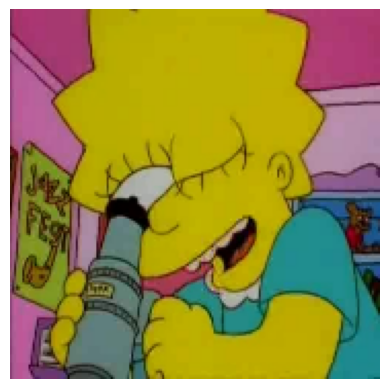

In [12]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

plt.imshow(images[0].numpy().astype("uint8"))
plt.axis("off")



In [15]:
print(labels[0].numpy())
print(train_ds.class_names[labels[0].numpy()])

2
lisa_simpson


In [16]:
#PİKSEL DEĞERLERİNİ KONTROL EDER

print(images[0].numpy().min())
print(images[0].numpy().max())

0.0
223.73842


In [20]:
dataset_path = "simpsons_data/simpsons_dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(180, 180),
    batch_size=32,
    class_names=characters,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(180, 180),
    batch_size=32,
    class_names=characters,
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 6361 files belonging to 5 classes.
Using 5089 files for training.
Found 6361 files belonging to 5 classes.
Using 1272 files for validation.


In [22]:
#DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [24]:
#RESCALING-NORMALİZASYON

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



In [23]:
# (image, label) train_ds içinde bu şekildedir

def augment(image, label):
    image = data_augmentation(image)
    return image, label

train_ds = train_ds.map(augment)

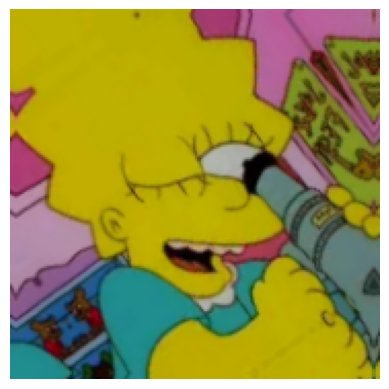

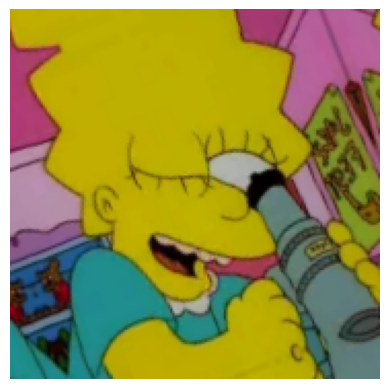

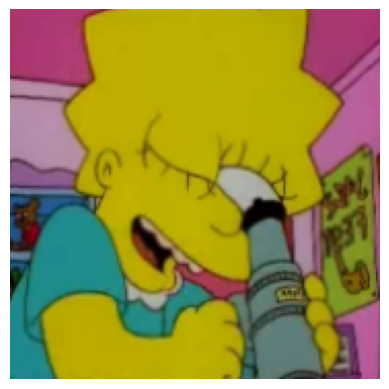

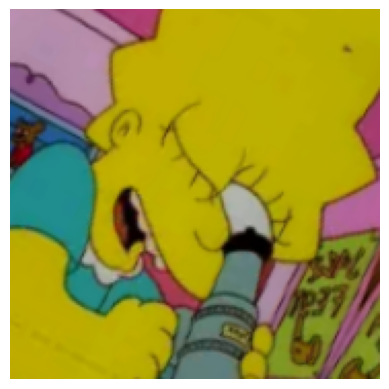

In [29]:
image = images[0]

image = tf.expand_dims(image, axis=0)

for i in range(4):
    augmented_image = data_augmentation(image)

    plt.figure()
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")
    plt.show()

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.4740 - loss: 1.5004 - val_accuracy: 0.5645 - val_loss: 1.0934
Epoch 2/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.6013 - loss: 0.9784 - val_accuracy: 0.6635 - val_loss: 0.9921
Epoch 3/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.6445 - loss: 0.8866 - val_accuracy: 0.6407 - val_loss: 0.9440
Epoch 4/5
 71/160 ━━━━━━━━━━━━━━━━━━━━ 3:06 2s/step - accuracy: 0.6590 - loss: 0.8737

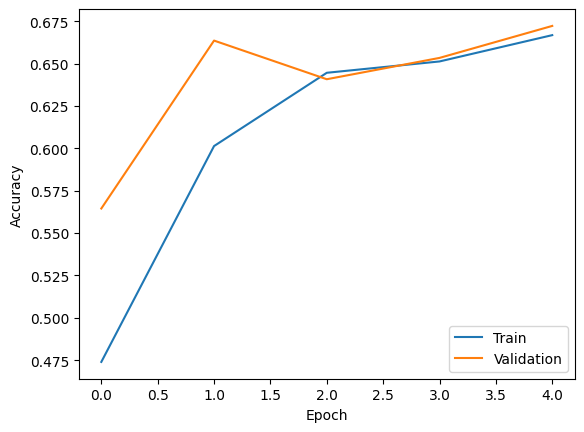

In [32]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["Train", "Validation"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [36]:
import numpy as np

# 1. Validation datasetinden ilk batch'i al
images, labels = next(iter(val_ds))

# 2. İlk resmi ve gerçek label'ını seç
test_image = images[0]
test_label = labels[0]

# 3. Gerçek karakteri bul
real_character = characters[test_label.numpy()]

print("Gerçek karakter:", real_character)

# 4. Resmi NumPy formatına çevir
test_image = test_image.numpy().astype("uint8")

# 5. Batch boyutu ekle
test_image = np.expand_dims(test_image, axis=0)

print("Model'e giden resim şekli:", test_image.shape)

# 6. CNN ile tahmin yap
prediction = model.predict(test_image)

# 7. En yüksek olasılığın index'ini bul
predicted_index = np.argmax(prediction[0])

# 8. Index'i karakter adına çevir
predicted_character = characters[predicted_index]

print("Modelin tahmini:", predicted_character)

Gerçek karakter: marge_simpson
Model'e giden resim şekli: (1, 180, 180, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Modelin tahmini: marge_simpson
